<a href="https://colab.research.google.com/github/MohHaroon/XAI-based-ZSL-for-IIDS/blob/master/model_train_eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Train and Evaluate the models - XGBoost, CatBoost, Decision tree

### EDA & Pre-processing the SDN dataset by Kaan Sarica and Angin 2020

#### EDA

In [ ]:
import pandas as pd

In [ ]:
# 0:Normal
# 1:DoS
# 2:DDoS
# 3:Port Scanning
# 4:OS Fingerprinting
# 5:Fuzzing

# for training
SDN_df_5 = pd.read_csv("/content/drive/MyDrive/IRP/SDN-Dataset/SDN-Dataset-master/SDN-Dataset-master/5-iot/35000_each.csv")

# for evaluation
SDN_df_10 = pd.read_csv("/content/drive/MyDrive/IRP/SDN-Dataset/SDN-Dataset-master/SDN-Dataset-master/10-iot/35000_each.csv")

In [ ]:
print(f"SDN_df_5 unique Labels: {SDN_df_5.columns}")
print(f"SDN_df_10 unique Labels: {SDN_df_10.columns}")

SDN_df_5 unique Labels: Index(['srcMAC', 'dstMAC', 'srcIP', 'dstIP', 'srcPort', 'dstPort', 'last_seen',
       'Protocol', 'proto_number', 'Dur', 'Mean', 'Stddev', 'Min', 'Max',
       'Pkts', 'Bytes', 'Spkts', 'Dpkts', 'Sbytes', 'Dbytes', 'Srate', 'Drate',
       'Sum', 'TnBPSrcIP', 'TnBPDstIP', 'TnP_PSrcIP', 'TnP_PDstIP',
       'TnP_PerProto', 'TnP_Per_Dport', 'N_IN_Conn_P_DstIP',
       'N_IN_Conn_P_SrcIP', 'Attack', 'Category'],
      dtype='object')
SDN_df_10 unique Labels: Index(['srcMAC', 'dstMAC', 'srcIP', 'dstIP', 'srcPort', 'dstPort', 'last_seen',
       'Protocol', 'proto_number', 'Dur', 'Mean', 'Stddev', 'Min', 'Max',
       'Pkts', 'Bytes', 'Spkts', 'Dpkts', 'Sbytes', 'Dbytes', 'Srate', 'Drate',
       'Sum', 'TnBPSrcIP', 'TnBPDstIP', 'TnP_PSrcIP', 'TnP_PDstIP',
       'TnP_PerProto', 'TnP_Per_Dport', 'N_IN_Conn_P_DstIP',
       'N_IN_Conn_P_SrcIP', 'Attack', 'Category'],
      dtype='object')


In [ ]:
print(f"SDN_df_5 shape: {SDN_df_5.shape}")
print(f"SDN_df_10 shape: {SDN_df_10.shape}")

SDN_df_5 shape: (210000, 33)
SDN_df_10 shape: (210000, 33)


In [ ]:
for col in SDN_df_5.columns:
    if SDN_df_5[col].isnull().any():
        print(f"SDN_df_5 has missing values in column: {col}")


SDN_df_5 has missing values in column: srcPort
SDN_df_5 has missing values in column: dstPort


#### Pre-processing


In [ ]:
SDN_df_model = SDN_df_5.copy()
SDN_df_model.drop(columns=['srcMAC', 'dstMAC', 'Protocol','srcIP', 'dstIP', 'srcPort', 'dstPort', 'last_seen'], inplace=True)

In [ ]:
print(f"Columns that are not numeric: {SDN_df_model.select_dtypes(exclude=['number']).columns.tolist()}")

Columns that are not numeric: []


In [ ]:
print(f"data types:\n{SDN_df_model.dtypes}")

data types:
proto_number         float64
Dur                  float64
Mean                 float64
Stddev               float64
Min                  float64
Max                  float64
Pkts                 float64
Bytes                float64
Spkts                float64
Dpkts                float64
Sbytes               float64
Dbytes               float64
Srate                float64
Drate                float64
Sum                  float64
TnBPSrcIP            float64
TnBPDstIP            float64
TnP_PSrcIP           float64
TnP_PDstIP           float64
TnP_PerProto         float64
TnP_Per_Dport        float64
N_IN_Conn_P_DstIP    float64
N_IN_Conn_P_SrcIP    float64
Attack               float64
Category             float64
dtype: object


In [ ]:
SDN_train_test_data = SDN_df_model.copy()
SDN_train_test_data.drop(columns=['Category'], inplace=True)

SDN_train_test_data.to_csv("/content/drive/MyDrive/IRP/SDN-Dataset/SDN_data.csv", index=False)

### Load Dataset

In [1]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
SDN_train_test_data = pd.read_csv("/content/drive/MyDrive/IRP/SDN-Dataset/SDN_data.csv")

In [5]:
def scale_data(data):
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    return scaled_data

In [6]:
SDN_scaled_data = scale_data(SDN_train_test_data.drop(columns=['Attack']))

In [7]:
def split_data(data, labels, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=test_size, random_state=random_state)
    return X_train, X_test, y_train, y_test

In [8]:
data_train, data_test, labels_train, labels_test = split_data(SDN_scaled_data, SDN_train_test_data['Attack'])

### Model Training and Evaluation

In [10]:
!pip install xgboost
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.5 MB/s eta 0:00:00


In [48]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import brier_score_loss
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import brier_score_loss
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, brier_score_loss, confusion_matrix


In [12]:
def train_and_evaluate_models(model, data_train, labels_train, data_test, labels_test):
  # Training Time
  start_train = time.time()
  model.fit(data_train, labels_train)
  end_train = time.time()
  training_duration = end_train - start_train

  # Inference Time
  start_inf = time.time()
  preds = model.predict(data_test)
  end_inf = time.time()
  inference_duration = (end_inf - start_inf) / len(data_test) # Average per packet

  probs = bst.predict_proba(data_test)[:, 1]
  bs = brier_score_loss(labels_test, probs)

  return preds, training_duration, inference_duration,bs

In [41]:
def plot_confusion_matrix(model, model_name, data_test, labels_test, preds):
  fig, ax = plt.subplots(figsize=(8, 6))
  ConfusionMatrixDisplay.from_predictions(labels_test, preds,
                                          display_labels=["Normal", "Attack"],
                                          cmap="Blues", ax=ax)
  plt.title(f"Confusion Matrix for {model_name}")
  plt.show()

  tn, fp, fn, tp = confusion_matrix(labels_test, preds).ravel()

  # Calculate FPR and FNR
  fpr = fp / (fp + tn)
  fnr = fn / (fn + tp)

  print(f"False Positive Rate (FPR): {fpr:.4f}")
  print(f"False Negative Rate (FNR): {fnr:.4f}")
  return fpr, fnr

def plot_auc_roc_curve(model, model_name, data_test, labels_test, preds):

  y_probs = model.predict_proba(data_test)[:, 1]
  score = roc_auc_score(labels_test, y_probs)

  fig, ax = plt.subplots(figsize=(8, 6))
  RocCurveDisplay.from_predictions(labels_test, y_probs, ax=ax, name=f"{model_name} (AUC={auc_score:.4f})")
  plt.plot([0, 1], [0, 1], "r--", label="Random Guess")
  plt.title("ROC Curve: Anomaly vs Normal Traffic")
  plt.legend()
  plt.show()
  return score


In [59]:
results_list = []

def collect_metrics(model_name, accuracy, precision, recall, f1_score, auc_roc,
                    bs, fpr, fnr, train_time, infer_time):


    # Calculate metrics
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1_score,
        "AUC-ROC": auc_roc,
        "Brier Score": bs,
        "FPR": fpr,
        "FNR": fnr,
        "Train Time (s)": train_time,
        "Inf. Time (ms/pkt)": infer_time*1000
    }

    results_list.append(metrics)
    return pd.DataFrame(results_list)

#### XGBoost

In [56]:
bst = XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic')

preds, training_duration_xgb, inference_duration_xgb,bs_xgb = train_and_evaluate_models(bst, data_train, labels_train, data_test, labels_test)

accuracy_xgb = accuracy_score(labels_test, preds)

print("-" * 60)
print("XGBoost Results:")
print(f"Overall Accuracy: {accuracy_xgb * 100:.2f}%")
print(f"Brier Score: {bs_xgb:.4f}")
print(f"Training Time: {training_duration_xgb:.2f} seconds")
print(f"Inference Time: {inference_duration_xgb:.10f} seconds per packet")
print("-" * 60)

print("Classification Report:")
report = classification_report(labels_test, preds, output_dict=True)
print(report)

------------------------------------------------------------
XGBoost Results:
Overall Accuracy: 95.01%
Brier Score: 0.0431
Training Time: 0.81 seconds
Inference Time: 0.0000003431 seconds per packet
------------------------------------------------------------
Classification Report:
{'0.0': {'precision': 0.848206599713056, 'recall': 0.8506474820143884, 'f1-score': 0.8494252873563218, 'support': 6950.0}, '1.0': {'precision': 0.9703682557807594, 'recall': 0.9698145506419401, 'f1-score': 0.9700913242009133, 'support': 35050.0}, 'accuracy': 0.9500952380952381, 'macro avg': {'precision': 0.9092874277469076, 'recall': 0.9102310163281643, 'f1-score': 0.9097583057786176, 'support': 42000.0}, 'weighted avg': {'precision': 0.9501534103124132, 'recall': 0.9500952380952381, 'f1-score': 0.9501239681040108, 'support': 42000.0}}


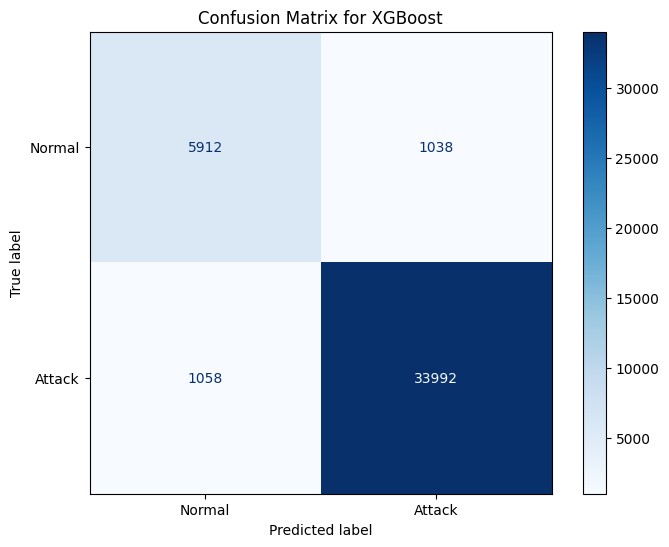

False Positive Rate (FPR): 0.1494
False Negative Rate (FNR): 0.0302


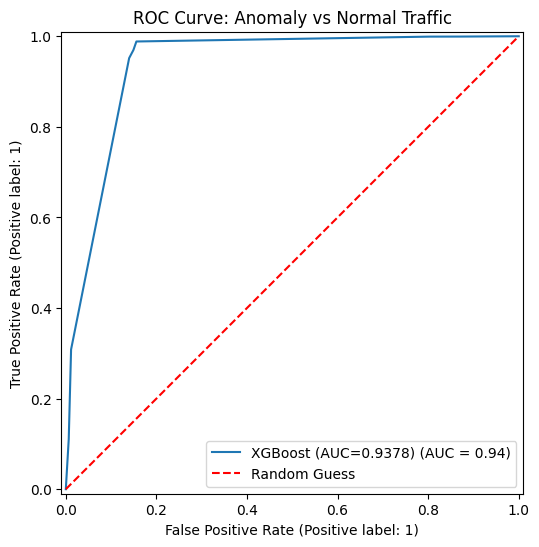

AUC-ROC Score: 0.9378


In [57]:
fpr_xgb,fnr_xgb = plot_confusion_matrix(bst, "XGBoost", data_test, labels_test, preds)
auc_roc_score_xgb = plot_auc_roc_curve(bst, "XGBoost", data_test, labels_test, preds)
print(f"AUC-ROC Score: {auc_roc_score_xgb:.4f}")

In [61]:
precision_xgb = report['1.0']['precision']
recall_xgb = report['1.0']['recall']
f1_xgb = report['1.0']['f1-score']

#model_name, accuracy, precision, recall, f1_score, auc_roc,bs, fpr, fnr, train_time, infer_time):
results_df = collect_metrics("XGBoost", accuracy_xgb, precision_xgb, recall_xgb,f1_xgb, auc_roc_score_xgb, bs_xgb, fpr_xgb, fnr_xgb, training_duration_xgb, inference_duration_xgb)



#### RFC

In [63]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

preds, training_duration_rf, inference_duration_rf,bs_rf = train_and_evaluate_models(rf_model, data_train, labels_train, data_test, labels_test)
accuracy_rf = accuracy_score(labels_test, preds)

print("-" * 60)
print("RF Results:")
print(f"Overall Accuracy: {accuracy_rf * 100:.2f}%")
print(f"Brier Score: {bs_rf:.4f}")
print(f"Training Time: {training_duration_rf:.2f} seconds")
print(f"Inference Time: {inference_duration_rf:.10f} seconds per packet")
print("-" * 60)

print("Classification Report:")
report = classification_report(labels_test, preds, output_dict=True)
print(report)

------------------------------------------------------------
RF Results:
Overall Accuracy: 98.75%
Brier Score: 0.0431
Training Time: 66.68 seconds
Inference Time: 0.0000125983 seconds per packet
------------------------------------------------------------
Classification Report:
{'0.0': {'precision': 0.9804126794258373, 'recall': 0.9434532374100719, 'f1-score': 0.9615779439800557, 'support': 6950.0}, '1.0': {'precision': 0.9888706388763027, 'recall': 0.9962624821683309, 'f1-score': 0.9925527983854922, 'support': 35050.0}, 'accuracy': 0.9875238095238095, 'macro avg': {'precision': 0.98464165915107, 'recall': 0.9698578597892014, 'f1-score': 0.9770653711827739, 'support': 42000.0}, 'weighted avg': {'precision': 0.9874710479672375, 'recall': 0.9875238095238095, 'f1-score': 0.9874271974779258, 'support': 42000.0}}


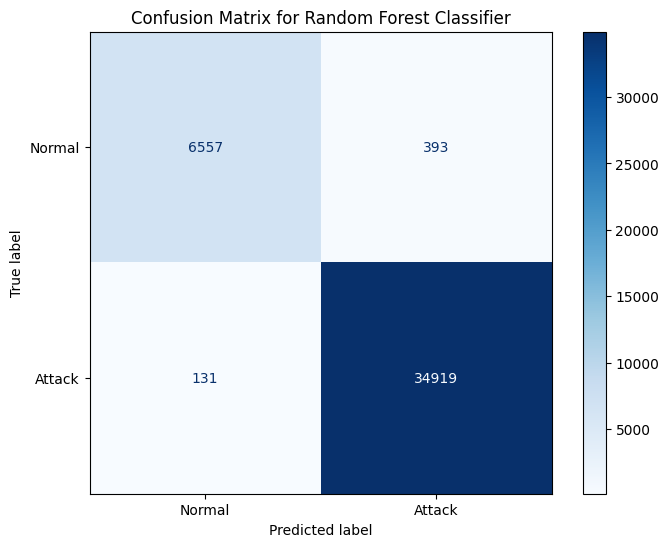

False Positive Rate (FPR): 0.0565
False Negative Rate (FNR): 0.0037


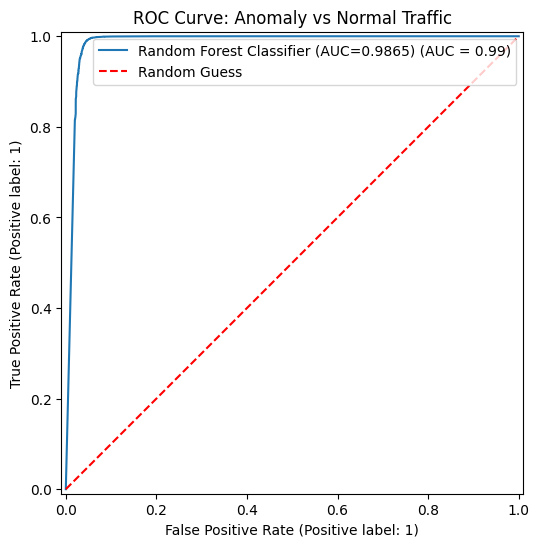

AUC-ROC Score: 0.9865


In [64]:
fpr_rfc,fnr_rfc = plot_confusion_matrix(rf_model, "Random Forest Classifier", data_test, labels_test, preds)
auc_roc_score_rfc = plot_auc_roc_curve(rf_model, "Random Forest Classifier", data_test, labels_test, preds)
print(f"AUC-ROC Score: {auc_roc_score_rfc:.4f}")

In [65]:
precision_rfc = report['1.0']['precision']
recall_rfc = report['1.0']['recall']
f1_rfc = report['1.0']['f1-score']

results_df = collect_metrics("Random Forest Classifier", accuracy_rf, precision_rfc, recall_rfc,f1_rfc, auc_roc_score_rfc, bs_rf, fpr_rfc, fnr_rfc, training_duration_rf, inference_duration_rf)

#### DT

In [66]:
dt_model = DecisionTreeClassifier(random_state=42)

preds, training_duration_dt, inference_duration_dt, bs_dt = train_and_evaluate_models(dt_model, data_train, labels_train, data_test, labels_test)
accuracy_dt = accuracy_score(labels_test, preds)

print("-" * 60)
print("DT Results:")
print(f"Overall Accuracy: {accuracy_dt * 100:.2f}%")
print(f"Brier Score: {bs_dt:.4f}")
print(f"Training Time: {training_duration_dt:.2f} seconds")
print(f"Inference Time: {inference_duration_dt:.10f} seconds per packet")
print("-" * 60)

print("Classification Report:")
report = classification_report(labels_test, preds, output_dict=True)
print(report)

------------------------------------------------------------
DT Results:
Overall Accuracy: 98.59%
Brier Score: 0.0431
Training Time: 5.19 seconds
Inference Time: 0.0000002173 seconds per packet
------------------------------------------------------------
Classification Report:
{'0.0': {'precision': 0.9706796979120391, 'recall': 0.9431654676258993, 'f1-score': 0.9567248047872728, 'support': 6950.0}, '1.0': {'precision': 0.9887933724856016, 'recall': 0.9943509272467903, 'f1-score': 0.9915643626328293, 'support': 35050.0}, 'accuracy': 0.9858809523809524, 'macro avg': {'precision': 0.9797365351988203, 'recall': 0.9687581974363448, 'f1-score': 0.9741445837100511, 'support': 42000.0}, 'weighted avg': {'precision': 0.985795990621643, 'recall': 0.9858809523809524, 'f1-score': 0.9857992453226718, 'support': 42000.0}}


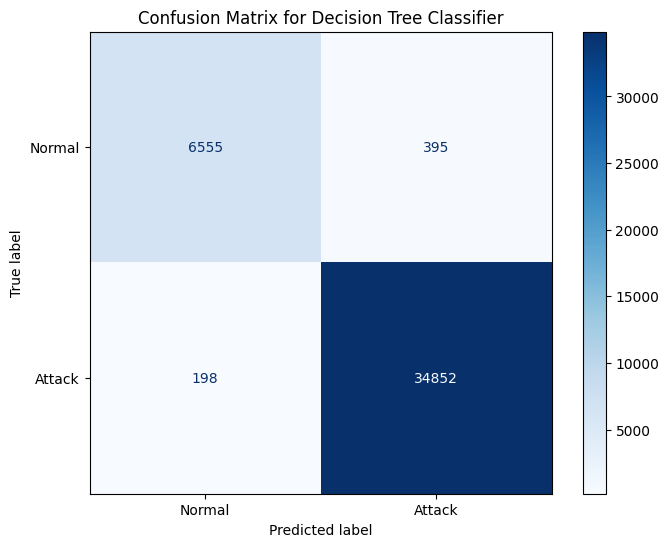

False Positive Rate (FPR): 0.0568
False Negative Rate (FNR): 0.0056


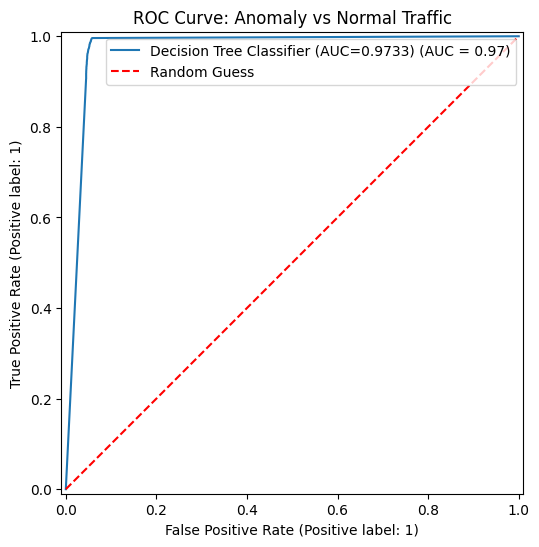

AUC-ROC Score: 0.9733


In [67]:
fpr_dt,fnr_dt = plot_confusion_matrix(dt_model, "Decision Tree Classifier", data_test, labels_test, preds)
auc_roc_score_dt = plot_auc_roc_curve(dt_model, "Decision Tree Classifier", data_test, labels_test, preds)
print(f"AUC-ROC Score: {auc_roc_score_dt:.4f}")

In [68]:
precision_dt = report['1.0']['precision']
recall_dt = report['1.0']['recall']
f1_dt = report['1.0']['f1-score']

results_df = collect_metrics("Decision Tree Classifier", accuracy_dt, precision_dt, recall_dt,f1_dt, auc_roc_score_dt, bs_dt, fpr_dt, fnr_dt, training_duration_dt, inference_duration_dt)

#### CatBoost

In [69]:
# Initialize CatBoost
# similar parameters to your XGBoost setup for a fair comparison
cat_model = CatBoostClassifier(iterations=100, depth=5, learning_rate=1, verbose=0)

preds, training_duration_cat, inference_duration_cat,bs_cat = train_and_evaluate_models(cat_model, data_train, labels_train, data_test, labels_test)
accuracy_cat = accuracy_score(labels_test, preds)

print("-" * 60)
print("CATBoost Results:")
print(f"Overall Accuracy: {accuracy_cat * 100:.2f}%")
print(f"Brier Score: {bs_cat:.4f}")
print(f"Training Time: {training_duration_cat:.2f} seconds")
print(f"Inference Time: {inference_duration_cat:.10f} seconds per packet")
print("-" * 60)

print("Classification Report:")
report = classification_report(labels_test, preds, output_dict=True)
print(report)

------------------------------------------------------------
CATBoost Results:
Overall Accuracy: 98.72%
Brier Score: 0.0431
Training Time: 5.86 seconds
Inference Time: 0.0000082308 seconds per packet
------------------------------------------------------------
Classification Report:
{'0.0': {'precision': 0.9837054918527459, 'recall': 0.9381294964028777, 'f1-score': 0.9603770805715127, 'support': 6950.0}, '1.0': {'precision': 0.9878434920275925, 'recall': 0.9969186875891584, 'f1-score': 0.9923603419385987, 'support': 35050.0}, 'accuracy': 0.9871904761904762, 'macro avg': {'precision': 0.9857744919401692, 'recall': 0.967524091996018, 'f1-score': 0.9763687112550556, 'support': 42000.0}, 'weighted avg': {'precision': 0.9871587515224691, 'recall': 0.9871904761904762, 'f1-score': 0.9870678736885689, 'support': 42000.0}}


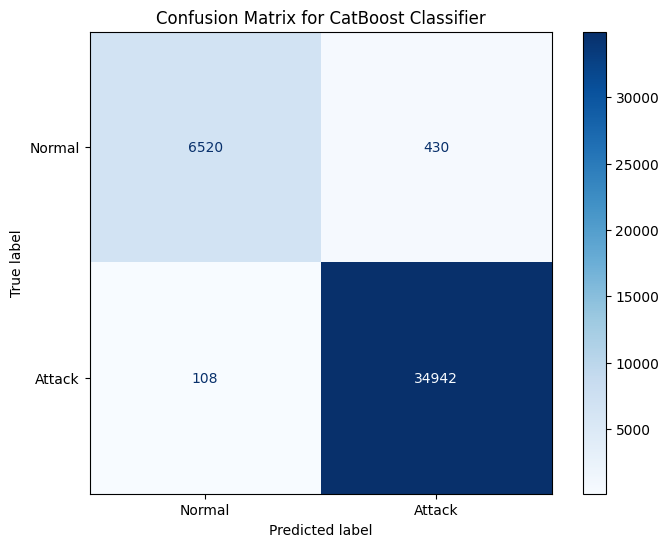

False Positive Rate (FPR): 0.0619
False Negative Rate (FNR): 0.0031


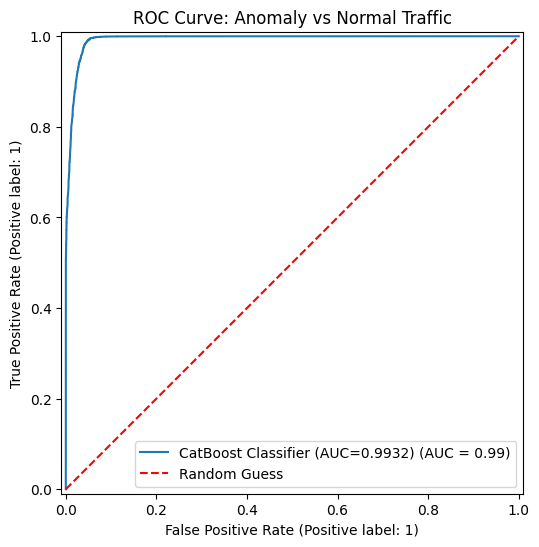

AUC-ROC Score: 0.9932


In [70]:
fpr_cat,fnr_cat = plot_confusion_matrix(cat_model, "CatBoost Classifier", data_test, labels_test, preds)
auc_roc_score_cat = plot_auc_roc_curve(cat_model, "CatBoost Classifier", data_test, labels_test, preds)
print(f"AUC-ROC Score: {auc_roc_score_cat:.4f}")

In [71]:
precision_cat = report['1.0']['precision']
recall_cat = report['1.0']['recall']
f1_cat = report['1.0']['f1-score']

results_df = collect_metrics("CatBoost Classifier", accuracy_cat, precision_cat, recall_cat,f1_cat, auc_roc_score_cat, bs_cat, fpr_cat, fnr_cat, training_duration_cat, inference_duration_cat)

In [84]:
# Display the final table
eval_table = results_df.sort_values(by="AUC-ROC", ascending=False)
eval_table

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Brier Score,FPR,FNR,Train Time (s),Inf. Time (ms/pkt)
4,CatBoost Classifier,0.987190,0.987843,0.996919,0.992360,0.993206,0.043118,0.061871,0.003081,5.860363,0.008231
2,Random Forest Classifier,0.987524,0.988871,0.996262,0.992553,0.986500,0.043118,0.056547,0.003738,66.682914,0.012598
3,Decision Tree Classifier,0.985881,0.988793,0.994351,0.991564,0.973261,0.043118,0.056835,0.005649,5.189427,0.000217
1,XGBoost,0.950095,0.970368,0.969815,0.970091,0.937759,0.043118,0.149353,0.030185,0.813197,0.000343
